## NGDS-Projekt - Gruppe H

Namen und E-Mail-Adressen der Gruppenmitglieder:

- Melchior von Weissenfluh vonwemel@students.zhaw.ch
- Nico Schellhaas schnic05@students.zhaw.ch

Zugeteilte Wetterstation: SMM

### Bibliotheken importieren und globale Parameter definieren

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import quad

### 1. Daten importieren und filtern

Importiert die Daten (Strings und Zahlen getrennt), wählt die relevanten Spalten und Zeilen aus. Am Ende sollt ihr je ein Array für den Messzeitpunkt (in Tagen seit der ersten Messung, nicht als Datetime Objekte) und die gemessenen Wetterdaten für eure Wetterstation haben.

In [3]:
# Strings laden (Station + Datum)
strings = np.genfromtxt("Daten/Graubuenden.csv", delimiter=",", dtype=str, skip_header=1)

# Numerische Daten laden
numbers = np.genfromtxt("Daten/Graubuenden.csv", delimiter=",", skip_header=1)

# Zeit in Tagen
time_array = numbers[:, 6]
# Wetterdaten
weather_array = numbers[:, 2:6]
# Station auswählen
station_mask = strings[:, 0] == "SMM"
time_array = time_array[station_mask]
weather_array = weather_array[station_mask]

# Test Form
print(time_array.shape)
print(weather_array.shape)


(7384,)
(7384, 4)


### 2. Interpolation

Wir haben 15% der Zeilen in den Originaldaten gelöscht. Also gibt es nicht genau stündlich Messwerte.

Bestimmt eine Interpolationsfunktion für jede Messgrösse und interpoliert die Messreihen viertelstündlich (d.h. für jede Stunde vier Werte plus den Endpunkt am 1. Januar um 0:00).

Wählt die Art und den Grad der Interpolation so aus, dass die interpolierten Werte auch physikalisch sinnvoll sind.

In [4]:
# 1. Spalten aus deinem weather_array extrahieren
# WICHTIG: Prüfe in der 'Legende' der CSV, ob die Reihenfolge stimmt!
luftdruck = weather_array[:, 0]
temperatur = weather_array[:, 1]
regen = weather_array[:, 2]
sonne = weather_array[:, 3]

# 2. Ziel-Zeitachse definieren (Viertelstündlich)
# Wir nutzen dein 'time_array'
t_interp = np.arange(0, time_array[-1], 1/(24*4))
t_interp = np.append(t_interp, time_array[-1]) # Endpunkt hinzufügen

# 3. Interpolationsfunktionen erstellen
# Kubisch für glatte Verläufe, Linear für Regen/Sonne (wegen physikalischer Sinnhaftigkeit)
f_temp = interp1d(time_array, temperatur, kind='cubic')
f_druck = interp1d(time_array, luftdruck, kind='cubic')
f_regen = interp1d(time_array, regen, kind='linear')
f_sonne = interp1d(time_array, sonne, kind='linear')

# 4. Neue Werte berechnen
temp_interp = f_temp(t_interp)
druck_interp = f_druck(t_interp)
regen_interp = f_regen(t_interp)
sonne_interp = f_sonne(t_interp)

### 3. Daten und Interpolation darstellen und vergleichen 

Um die Interpolation zu überprüfen, stellt für alle Variablen jeweils die Daten und die Interpolationsfunktion zusammen grafisch dar.

Wählt dazu ein Zeitfenster von ein paar Tagen, in dem alle Variablen ein etwas interessantes Verhalten zeigen, d.h. es fällt Regen und die Sonne scheint.

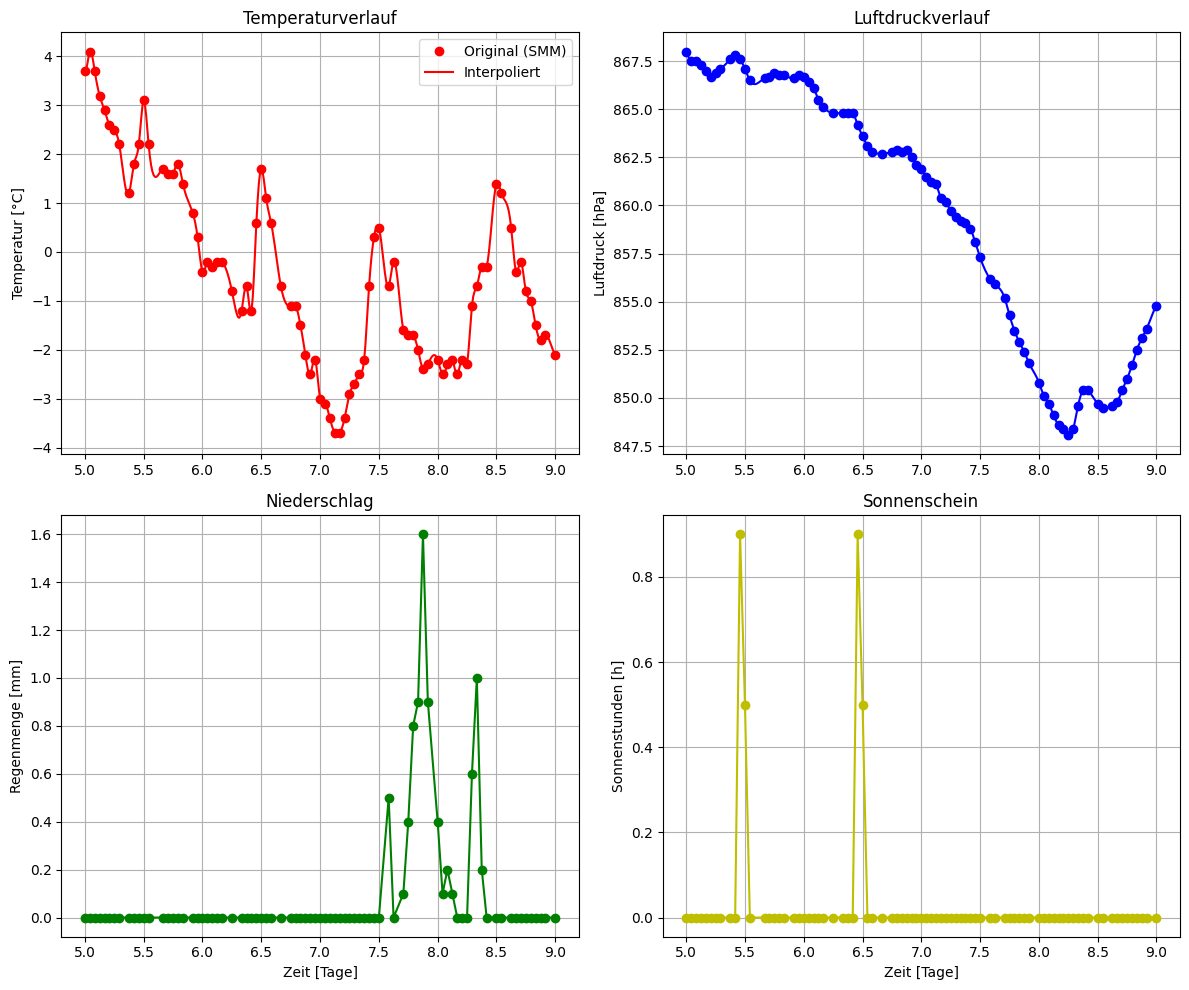

In [ ]:
# Zeitfenster wählen (z.B. 3 Tage in der Mitte des Jahres)
t_start, t_end = 5, 9 

# Masken erstellen, um nur diesen Zeitraum zu plotten
m_orig = (time_array >= t_start) & (time_array <= t_end)
m_new = (t_interp >= t_start) & (t_interp <= t_end)

# Layout erstellen: 2 Zeilen, 2 Spalten
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# 1. Temperatur Plot (Oben Links -> Zeile 0, Spalte 0)
axs[0, 0].plot(time_array[m_orig], temperatur[m_orig], 'ro', label='Original (SMM)')
axs[0, 0].plot(t_interp[m_new], temp_interp[m_new], 'r-', label='Interpoliert')
axs[0, 0].set_ylabel('Temperatur [°C]')
axs[0, 0].set_title('Temperaturverlauf')
axs[0, 0].legend()
axs[0, 0].grid(True)

# 2. Luftdruck Plot (Oben Rechts -> Zeile 0, Spalte 1)
axs[0, 1].plot(time_array[m_orig], luftdruck[m_orig], 'bo')
axs[0, 1].plot(t_interp[m_new], druck_interp[m_new], 'b-')
axs[0, 1].set_ylabel('Luftdruck [hPa]')
axs[0, 1].set_title('Luftdruckverlauf')
axs[0, 1].grid(True)

# 3. Regen Plot (Unten Links -> Zeile 1, Spalte 0)
axs[1, 0].plot(time_array[m_orig], regen[m_orig], 'go')
axs[1, 0].plot(t_interp[m_new], regen_interp[m_new], 'g-')
axs[1, 0].set_ylabel('Regenmenge [mm]')
axs[1, 0].set_xlabel('Zeit [Tage]')
axs[1, 0].set_title('Niederschlag')
axs[1, 0].grid(True)

# 4. Sonne Plot (Unten Rechts -> Zeile 1, Spalte 1)
axs[1, 1].plot(time_array[m_orig], sonne[m_orig], 'yo')
axs[1, 1].plot(t_interp[m_new], sonne_interp[m_new], 'y-')
axs[1, 1].set_ylabel('Sonnenstunden [h]')
axs[1, 1].set_xlabel('Zeit [Tage]')
axs[1, 1].set_title('Sonnenschein')
axs[1, 1].grid(True)

# Verhindert, dass sich Titel und Achsenbeschriftungen überschneiden
plt.tight_layout()
plt.show()

### 4. Nullstellen der Temperatur bestimmen

Wählt einen Zeitraum von ca. einer Woche, in der die Temperatur um Null herum schwankt. 

Bestimmt die Zeitpunkte, an denen die Temperatur den Wert Null hat. Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

Stellt die Temperatur und die Nullstellen zusammen grafisch dar.

Alternativ (und ein wenig schwieriger) könnt ihr auch einen Zeitraum wählen, in der die Temperatur hohe Werte erreicht. Bestimmt dann die Zeitpunkte, an denen die Temperatur einen bestimmten Hitzewert überschreitet, z.B. 30 Grad.

### 5. Grosse Schwankungen in Temperatur oder Luftdruck finden

Betrachtet entweder die Temperatur oder den Luftdruck übers ganze Jahr. Berechnet die Ableitung der gewählten Variable und stellt diese auch dar, um einen Zeitraum von ca. 1 Woche mit grossen Schwankungen zu finden. Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

In der gewählten Woche mit grossen Schwankungen sollen nun die Zeitpunkte bestimmt werden, zu denen die Temperatur bzw. der Luftdruck am stärksten steigt bzw. fällt, also das Maximum und das Minimum der Ableitung.

Um das Maximum/Minimum eines Arrays zu finden, könnt ihr die Funktionen [`np.argmax`](https://numpy.org/doc/stable//reference/generated/numpy.argmax.htm) und [`np.argmin`](https://numpy.org/doc/stable//reference/generated/numpy.argmin.html) verwenden. 

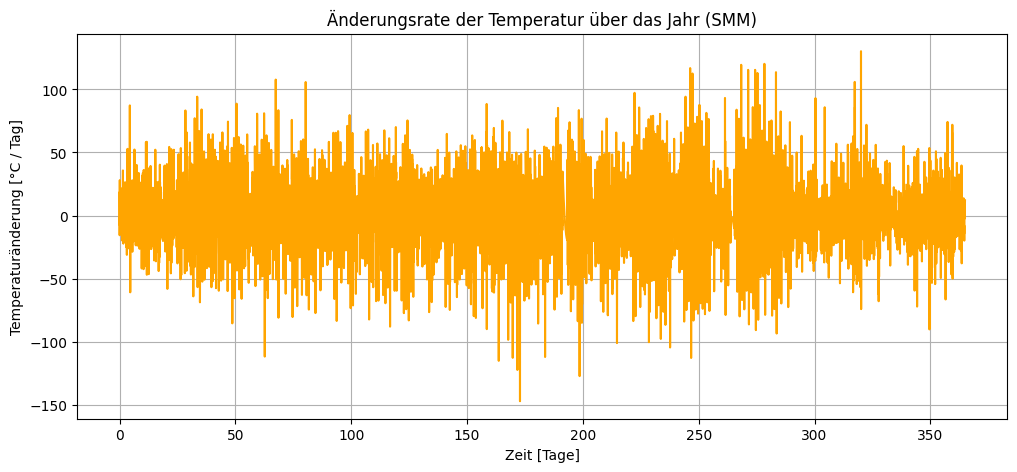

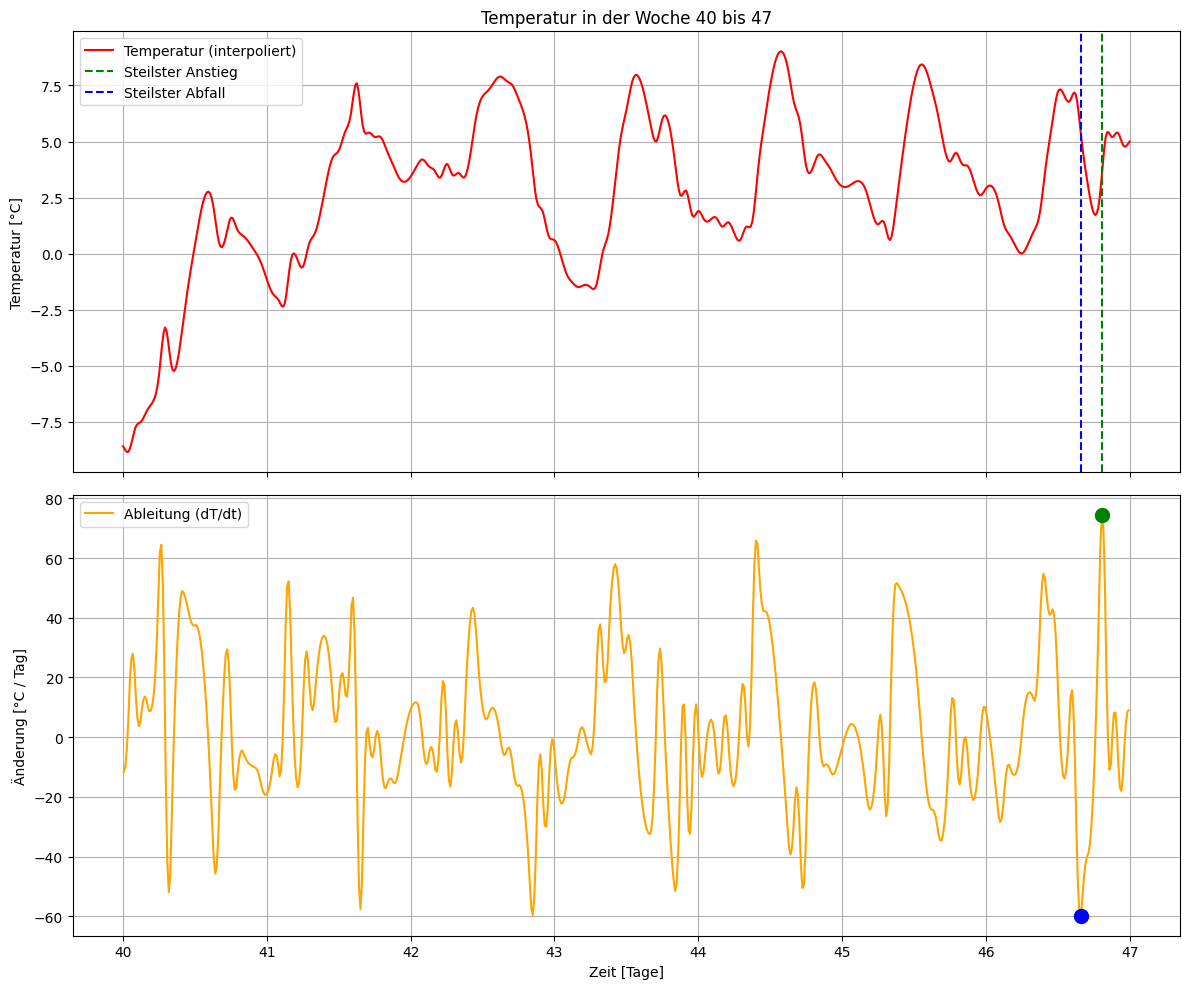

Der stärkste Temperaturanstieg war an Tag 46.81
Der stärkste Temperaturabfall war an Tag 46.66


In [8]:
# Zeitabstand zwischen zwei Punkten (in Tagen)
dt = t_interp[1] - t_interp[0]

# Numerische Ableitung: (T_nachher - T_vorher) / dt
# np.diff berechnet die Differenz zwischen aufeinanderfolgenden Elementen
temp_ableitung = np.diff(temp_interp) / dt

# Da np.diff das Array um 1 kürzt, brauchen wir eine passende Zeitachse für die Ableitung
t_ableitung = t_interp[:-1] + dt/2 

# Plot über das ganze Jahr, um Schwankungen zu finden
plt.figure(figsize=(12, 5))
plt.plot(t_ableitung, temp_ableitung, color='orange')
plt.title('Änderungsrate der Temperatur über das Jahr (SMM)')
plt.ylabel('Temperaturänderung [°C / Tag]')
plt.xlabel('Zeit [Tage]')
plt.grid(True)
plt.show()


# WÄHLE HIER DEINE WOCHE (Beispiel: Tag 40 bis 47)
t_start_woche = 40 
t_end_woche = 47

# Masken für die gewählte Woche
mask_woche_interp = (t_interp >= t_start_woche) & (t_interp <= t_end_woche)
mask_woche_ableitung = (t_ableitung >= t_start_woche) & (t_ableitung <= t_end_woche)

# Daten für die Woche extrahieren
t_woche = t_interp[mask_woche_interp]
temp_woche = temp_interp[mask_woche_interp]
t_abl_woche = t_ableitung[mask_woche_ableitung]
abl_woche = temp_ableitung[mask_woche_ableitung]

# Zeitpunkte der stärksten Änderung finden (Maximum und Minimum der Ableitung)
idx_max = np.argmax(abl_woche)
idx_min = np.argmin(abl_woche)

t_max_anstieg = t_abl_woche[idx_max]
t_max_fall = t_abl_woche[idx_min]

# Darstellung
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharex=True)

# Plot 1: Temperaturverlauf
ax1.plot(t_woche, temp_woche, 'r-', label='Temperatur (interpoliert)')
ax1.axvline(t_max_anstieg, color='green', linestyle='--', label='Steilster Anstieg')
ax1.axvline(t_max_fall, color='blue', linestyle='--', label='Steilster Abfall')
ax1.set_ylabel('Temperatur [°C]')
ax1.set_title(f'Temperatur in der Woche {t_start_woche} bis {t_end_woche}')
ax1.legend()
ax1.grid(True)

# Plot 2: Ableitung
ax2.plot(t_abl_woche, abl_woche, 'orange', label='Ableitung (dT/dt)')
ax2.scatter(t_max_anstieg, abl_woche[idx_max], color='green', s=100, zorder=5)
ax2.scatter(t_max_fall, abl_woche[idx_min], color='blue', s=100, zorder=5)
ax2.set_ylabel('Änderung [°C / Tag]')
ax2.set_xlabel('Zeit [Tage]')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

print(f"Der stärkste Temperaturanstieg war an Tag {t_max_anstieg:.2f}")
print(f"Der stärkste Temperaturabfall war an Tag {t_max_fall:.2f}")

### 6. Mittelwerte berechnen

Wählt eine der Messgrössen aus und berechnet den Mittelwert über das ganze Jahr und den Mittelwert pro Monat (1 Monat = 1/12 des Jahres). Nutzt dazu die Interpolationsfunktion der Temperatur aus Schritt 2 und nicht die Originaldaten.

Stellt die eigentliche Variable und die Mittelwerte zusammen grafisch dar.

Die Mittelung soll mithilfe der Integration über die Interpolationsfunktion aus Schritt 2 berechnet werden.

Bei der Integration kann es Warnungen geben, da die Interpolationsfunktionen teils stark schwanken. Es kann hilfreich sein, mit dem Parameter `limit` die Anzahl Subintervalle zu erhöhen. Probiert aus, ab wann sich das Resultat nicht mehr gross ändert.

*Empfehlungen:* 
- Implementiert dies zuerst für die Temperatur, da diese am einfachsten zu interpretieren ist. Dann könnt ihr immer noch die anderen Messgrössen betrachten.
- Beginnt mit dem Mittelwert über das ganze Jahr, dann verallgemeinert für ein beliebiges Zeitintervall und iteriert schliesslich über die Monate.

/var/folders/yf/fmfsxw9150n3zs4sklkn8rg40000gn/T/ipykernel_67199/4008772264.py:6: IntegrationWarning: The maximum number of subdivisions (1000) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  integral, error = quad(interp_func, start, ende, limit=1000)
/var/folders/yf/fmfsxw9150n3zs4sklkn8rg40000gn/T/ipykernel_67199/4008772264.py:6: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  integral, error = quad(interp_func, start, ende, limit=1000)


Jahresmittelwert (SMM): 7.68 °C


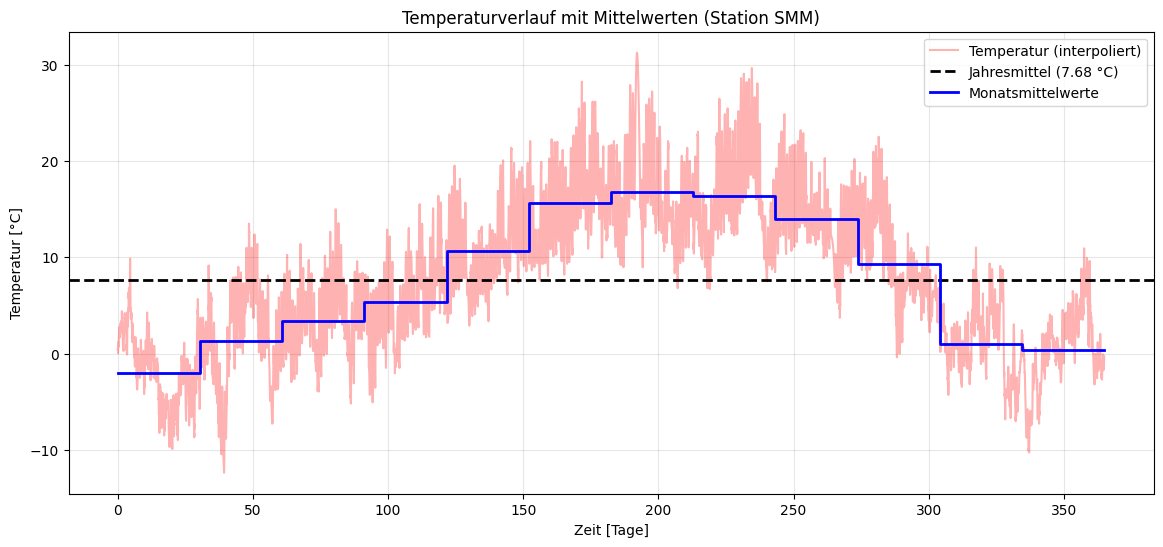

In [14]:
from scipy.integrate import quad

# Funktion zur Berechnung des Mittelwerts in einem beliebigen Intervall
def berechne_mittelwert(interp_func, start, ende):
    # Wir erhöhen das Limit von 100 auf 1000
    integral, error = quad(interp_func, start, ende, limit=1000)
    return integral / (ende - start)
# 1. Mittelwert über das ganze Jahr
t_start_jahr = time_array[0]
t_ende_jahr = time_array[-1]
mittel_jahr = berechne_mittelwert(f_temp, t_start_jahr, t_ende_jahr)

# 2. Mittelwert pro Monat (1 Monat = 1/12 des Jahres)
monate = 12
dt_monat = (t_ende_jahr - t_start_jahr) / monate
mittel_monate = []
t_monat_zentren = []

for i in range(monate):
    m_start = t_start_jahr + i * dt_monat
    m_ende = m_start + dt_monat
    m_wert = berechne_mittelwert(f_temp, m_start, m_ende)
    
    mittel_monate.append(m_wert)
    t_monat_zentren.append(m_start + dt_monat/2) # Punkt für die Darstellung in der Mitte des Monats

print(f"Jahresmittelwert (SMM): {mittel_jahr:.2f} °C")


plt.figure(figsize=(14, 6))

# Gesamter Temperaturverlauf (leicht transparent im Hintergrund)
plt.plot(t_interp, temp_interp, color='red', alpha=0.3, label='Temperatur (interpoliert)')

# Jahresmittelwert als horizontale Linie
plt.axhline(mittel_jahr, color='black', linestyle='--', linewidth=2, label=f'Jahresmittel ({mittel_jahr:.2f} °C)')

# Monatsmittelwerte als Treppenstufen oder markante Punkte
# 'where='post'' sorgt dafür, dass die Linie den ganzen Monat auf dem Level bleibt
plt.step(np.linspace(t_start_jahr, t_ende_jahr, monate+1), 
         [mittel_monate[0]] + mittel_monate, 
         color='blue', linewidth=2, label='Monatsmittelwerte')

plt.title('Temperaturverlauf mit Mittelwerten (Station SMM)')
plt.ylabel('Temperatur [°C]')
plt.xlabel('Zeit [Tage]')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### 7. Glättung (Gleitendes Mittel) bestimmen

Nehmt die gleiche Messgrösse wie in Schritt 6 und berechnet das gleitende Mittel über das ganze Jahr. Dazu soll die Faltung mit einer symmetrischen Rechteckfunktion verwendet werden. Die Fensterbreite (Breite des Rechtecks) soll ein Parameter sein, den ihr variieren könnt.

Stellt die Messgrösse und das gleitende Mittel mit Fensterbreite = 7 Tage zusammen dar. Optional könnt ihr dazu auch noch das gleitende Mittel mit Fensterbreite = 14 und/oder 28 Tage darstellen.

Entscheidet selbst, ob ihr die kontinuierliche Faltung (Integration) oder die diskrete Faltung (Matrixmultiplikation) benutzt. 

*Vorsicht:* Die kontinuierliche Faltung (Integration) ist rechenintensiv. Berechnet also zuerst das gleitende Mittel an wenigen Zeitpunkten über das ganze Jahr, z.B. 100, und erhöht dann die Anzahl Zeitpunkte vorsichtig.

### Zusammenfassung

### Reflexion

Mitglied 1:
- Was hat gut funktioniert?
- Was hat nicht gut funktioniert?
- Was würdest du beim nächsten Mal anders machen?
- Was hast du gelernt?
- Was war die grösste Herausforderung?
- usw.


Mitglied 2:
- Was hat gut funktioniert?
- Was hat nicht gut funktioniert?
- Was würdest du beim nächsten Mal anders machen?
- Was hast du gelernt?
- Was war die grösste Herausforderung?
- usw.

Mitglied 3:
- Was hat gut funktioniert?
- Was hat nicht gut funktioniert?
- Was würdest du beim nächsten Mal anders machen?
- Was hast du gelernt?
- Was war die grösste Herausforderung?
- usw.